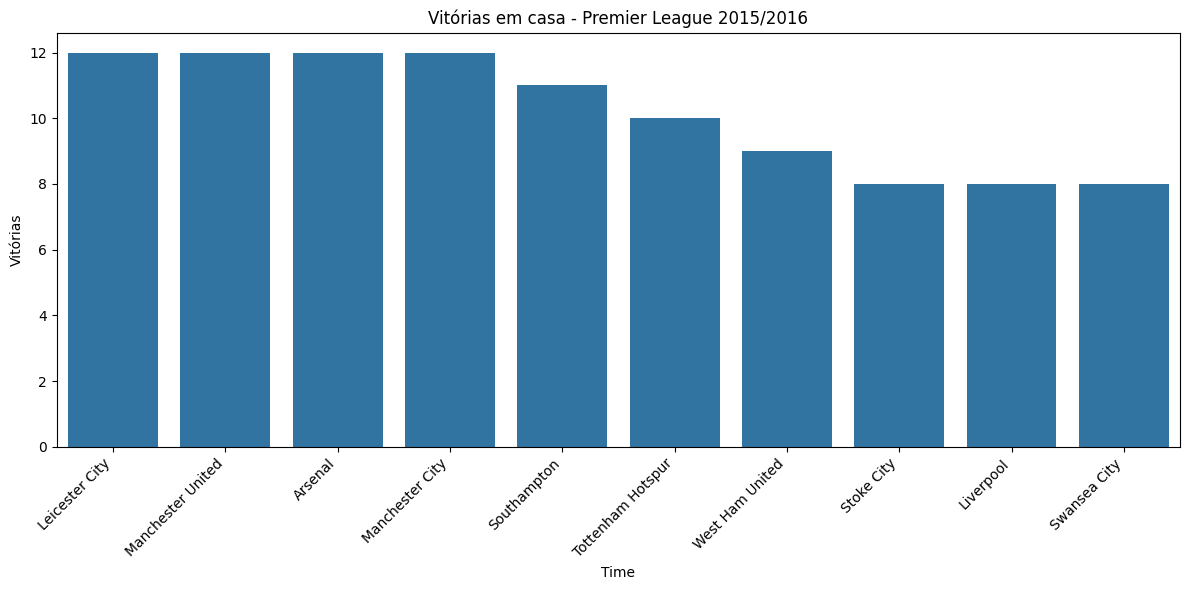

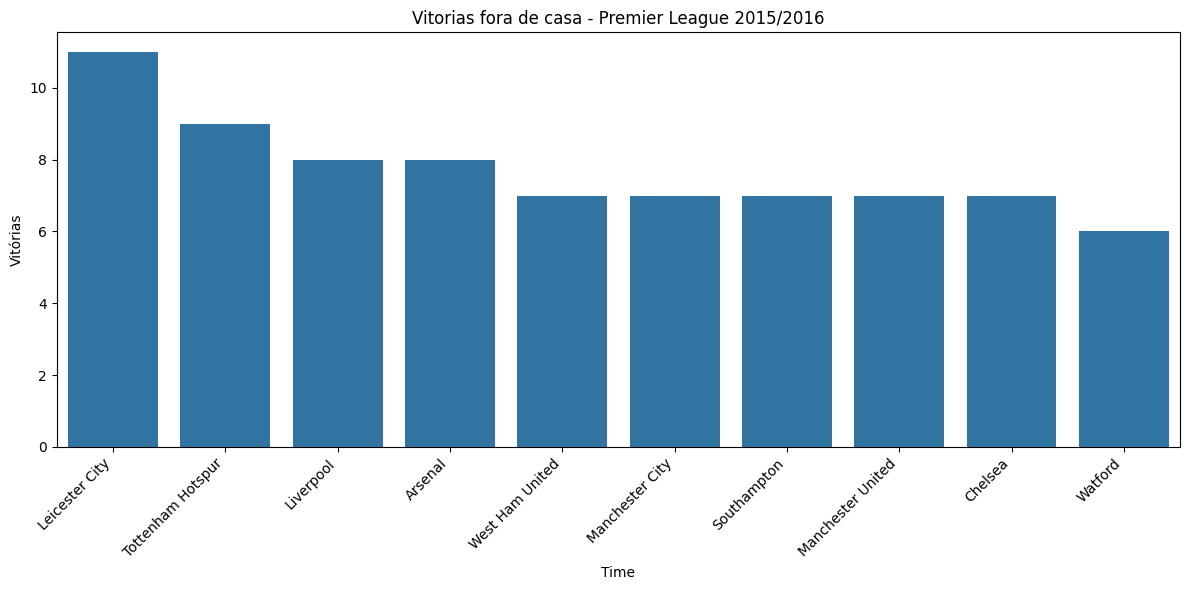

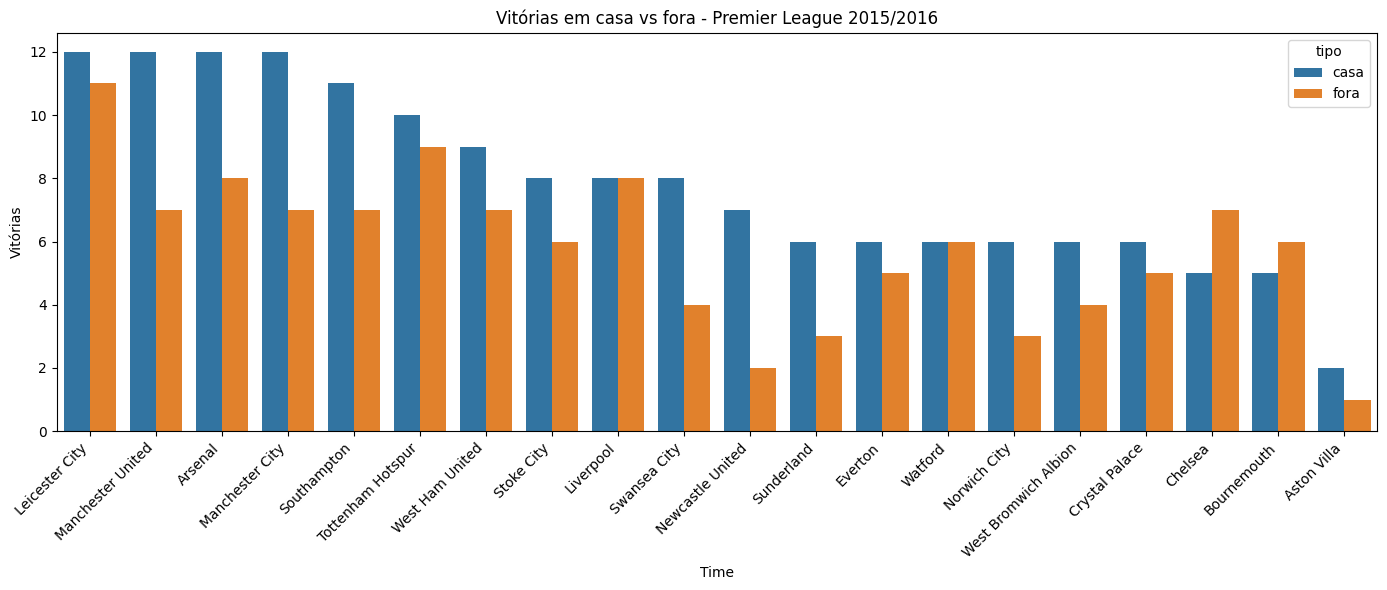

In [75]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('database.sqlite')

tabelas = pd.read_sql("SELECT name from sqlite_master where type='table'", conn)
tabelas

df_match = pd.read_sql("select * from match", conn)
df_team = pd.read_sql("select * from team", conn)
df_player = pd.read_sql("select * from player", conn)

df_league = pd.read_sql("select * from league", conn)
df_league

df_premier = df_match[df_match['league_id'] == 1729]

df_1516 = df_premier[df_premier['season'] == '2015/2016']
df_1516['result'] = df_1516.apply(lambda row: 'home_win' if row['home_team_goal'] > row['away_team_goal']
                                        else 'away_win' if row['home_team_goal'] < row['away_team_goal']
                                        else 'draw',
                                        axis=1)

df_1516['result'].value_counts()

home_wins = df_1516[df_1516['result'] == 'home_win']
home_wins_count = home_wins['home_team_api_id'].value_counts()
away_wins = df_1516[df_1516['result'] == 'away_win']
away_wins_count = away_wins['away_team_api_id'].value_counts()

home_table = home_wins_count.reset_index()
home_table.columns = ['team_api_id', 'wins']
home_table = home_table.merge(df_team, on='team_api_id')
home_table.sort_values('wins', ascending=False).head(10)

away_table = away_wins_count.reset_index()
away_table.columns = ['team_api_id', 'wins']
away_table = away_table.merge(df_team, on='team_api_id')
away_table.sort_values('wins', ascending=False).head(10)

home_table_clean = home_table[['team_long_name', 'wins']]
away_table_clean = away_table[['team_long_name', 'wins']]

home_table_clean.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=home_table_clean.head(10), x='team_long_name', y='wins')
plt.title('Vitórias em casa - Premier League 2015/2016')
plt.xlabel('Time')
plt.ylabel('Vitórias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(data=away_table_clean.head(10), x='team_long_name', y='wins')
plt.title('Vitorias fora de casa - Premier League 2015/2016')
plt.xlabel('Time')
plt.ylabel('Vitórias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

home_table_clean['tipo'] = 'casa'
away_table_clean['tipo'] = 'fora'

# junta os dois
df_comparacao = pd.concat([home_table_clean, away_table_clean])

plt.figure(figsize=(14, 6))
sns.barplot(data=df_comparacao, x='team_long_name', y='wins', hue='tipo')
plt.title('Vitórias em casa vs fora - Premier League 2015/2016')
plt.xlabel('Time')
plt.ylabel('Vitórias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()